# Deep Hedging research walkthrough

An end-to-end tour of the project's findings, working from the committed CSV and PNG artefacts in `results/`. No new computation: every cell either renders a previously generated figure or reads the held-out comparison table.

The companion documents are `README.md` (skim) and `docs/writeup.md` (depth).

## 1. Setup

Imports and the held-out comparison table.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS = Path('..') / 'results'
df = pd.read_csv(RESULTS / '02_neural_hedger_comparison.csv')
df

,cost_bps,bs_mean,bs_std,bs_q05,bs_q95,bs_cvar50,nn_mean,nn_std,nn_q05,nn_q95,nn_cvar50,nn_minus_bs_cvar50,nn_beats_bs_frac
0,0.0,0.001896,0.970295,-1.590595,1.583670,-0.726806,0.001565,0.979981,-1.634503,1.558551,-0.735903,-0.009097,0.46120
1,5.0,-0.163172,0.977104,-1.791607,1.403167,-0.895970,-0.159819,0.990550,-1.814880,1.412885,-0.906695,-0.010726,0.47782
2,25.0,-0.823446,1.028417,-2.619557,0.716840,-1.597399,-0.690113,1.074652,-2.497290,1.004003,-1.498827,0.098572,0.59267
3,50.0,-1.648787,1.139511,-3.707030,-0.043475,-2.520570,-1.246961,1.181329,-3.206428,0.644389,-2.146159,0.374411,0.66582


## 2. The hedging problem

An option seller writes a European call on a single underlying with strike `K` and maturity `T`, receives a fixed premium at `t = 0`, and may rebalance a hedge in the underlying at the discrete grid `t_n = nT/N`, `n = 0, ..., N - 1`. Each rebalance pays a proportional cost equal to `(bps / 10_000)` times the absolute share change times spot.

Under continuous trading and zero costs, Black-Scholes delta hedging is optimal. Under discrete rebalancing and non-zero costs, it is not — and there is no closed form for the policy that minimises a coherent risk measure of terminal P&L. Deep Hedging trains a neural network policy end-to-end against CVaR-50% of terminal P&L, with the path simulator, the cost model, the position recursion, and the loss all implemented as differentiable torch operations.

Setup throughout: `S_0 = K = 100`, `T = 1` year, `r = 0`, `sigma = 0.20`, `N = 50` rebalances, premium fixed at the frictionless BS price across all cost levels.

## 3. Frictionless baseline

Black-Scholes delta hedging at 0 bps over 100,000 paths. The terminal P&L is centred at $0.002 with standard deviation $0.970 — pure discrete-rebalance error. This reproduces the textbook result and validates the simulator, pricer, and cost-aware P&L accounting end to end.

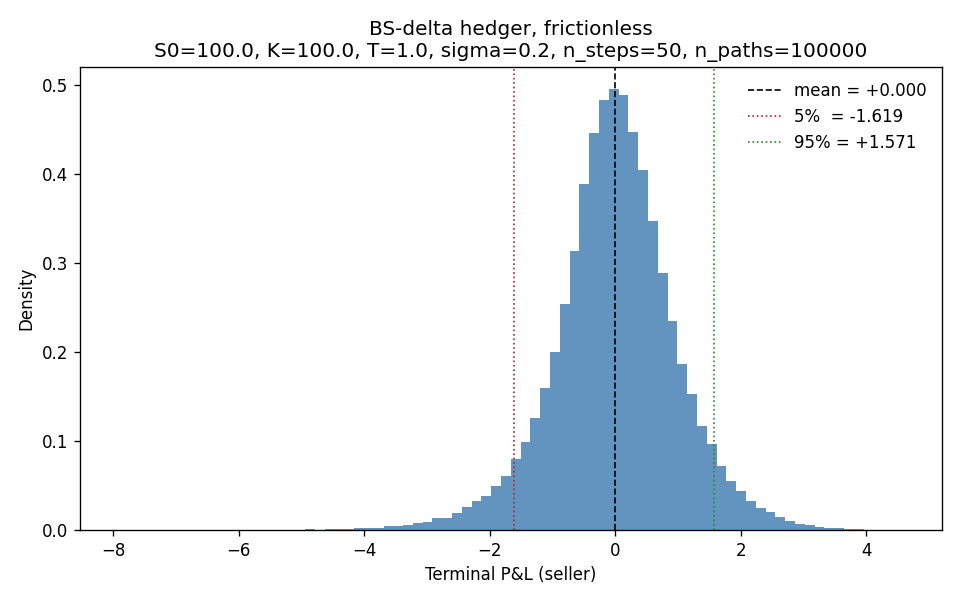

In [2]:
Image(filename=str(RESULTS / '01_bs_delta_frictionless.png'))

## 4. Cost impact on Black-Scholes

Switching the same paths to 5 bps shifts the BS distribution leftward: mean -$0.163, standard deviation $0.977. The shape is preserved; the entire distribution is translated. This is the friction-induced bleed an optimal cost-aware hedger should reduce.

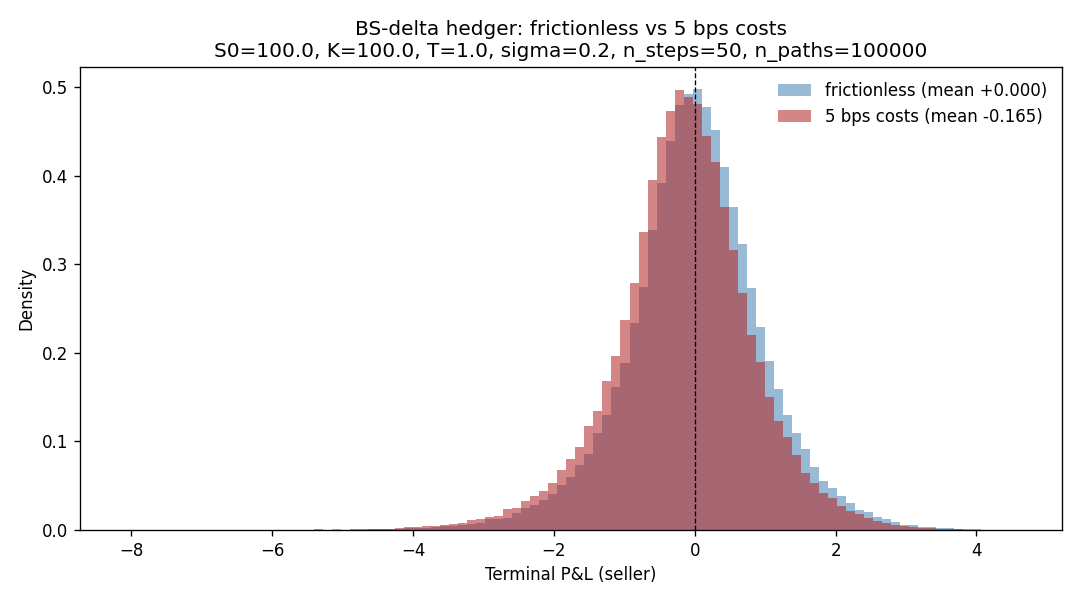

In [3]:
Image(filename=str(RESULTS / '01_bs_delta_with_costs.png'))

## 5. Neural hedger

A separate policy is trained at each cost level (4 input features, 32x32x32 MLP, CVaR-50% loss, Adam at 1e-3, 200 epochs at 0/5 bps and 500 at 25/50 bps). All four are evaluated on a *shared* 100,000-path held-out set, so the only thing varying across rows is the cost level.

Headline columns from the comparison table:

In [4]:
summary = df[[
    'cost_bps', 'bs_mean', 'bs_cvar50',
    'nn_mean', 'nn_cvar50',
    'nn_minus_bs_cvar50', 'nn_beats_bs_frac',
]].round(4)
summary

,cost_bps,bs_mean,bs_cvar50,nn_mean,nn_cvar50,nn_minus_bs_cvar50,nn_beats_bs_frac
0,0.0,0.0019,-0.7268,0.0016,-0.7359,-0.0091,0.4612
1,5.0,-0.1632,-0.8960,-0.1598,-0.9067,-0.0107,0.4778
2,25.0,-0.8234,-1.5974,-0.6901,-1.4988,0.0986,0.5927
3,50.0,-1.6488,-2.5206,-1.2470,-2.1462,0.3744,0.6658


Three things to read off this table.

- **0 bps** is a sanity check, not a result. BS is provably optimal in the frictionless limit; the NN should not beat it. The gap of -0.009 in CVaR-50% is well inside Monte Carlo noise. The training script includes a zero-cost gate that raises if the NN beats BS by more than ~`max(0.05, 5%·|bs_cvar|)` at 0 bps; the gate did not trigger.
- **5 bps** is noise-dominated. The CVaR gap (-0.011) is the same order of magnitude as the 0-bps gap.
- **25 and 50 bps** are where the framework earns its keep: monotonic CVaR-50% improvement (+0.099, +0.374) and the fraction of paths on which NN strictly beats BS rising from a coin flip to two-thirds.

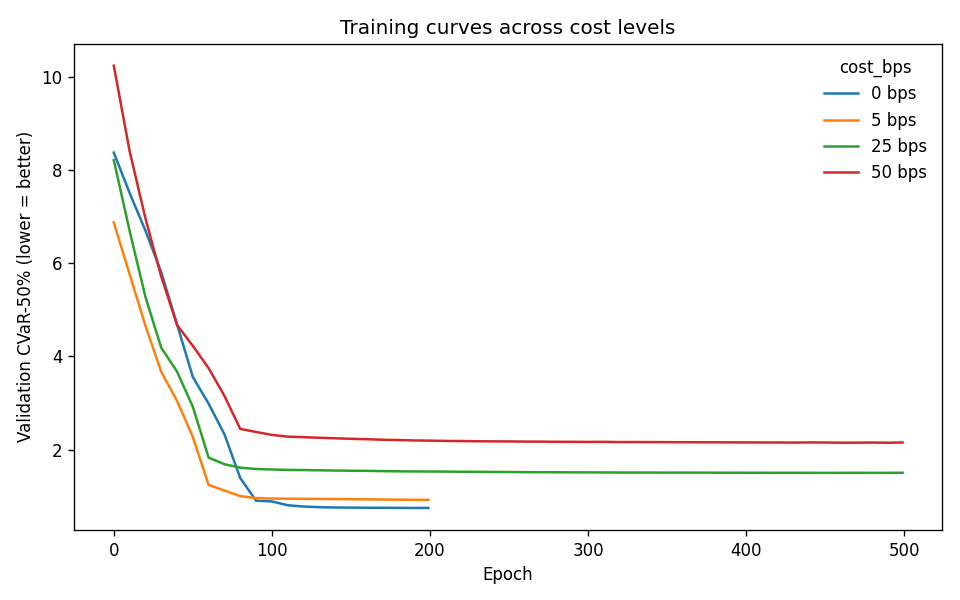

In [5]:
Image(filename=str(RESULTS / '02_loss_curves.png'))

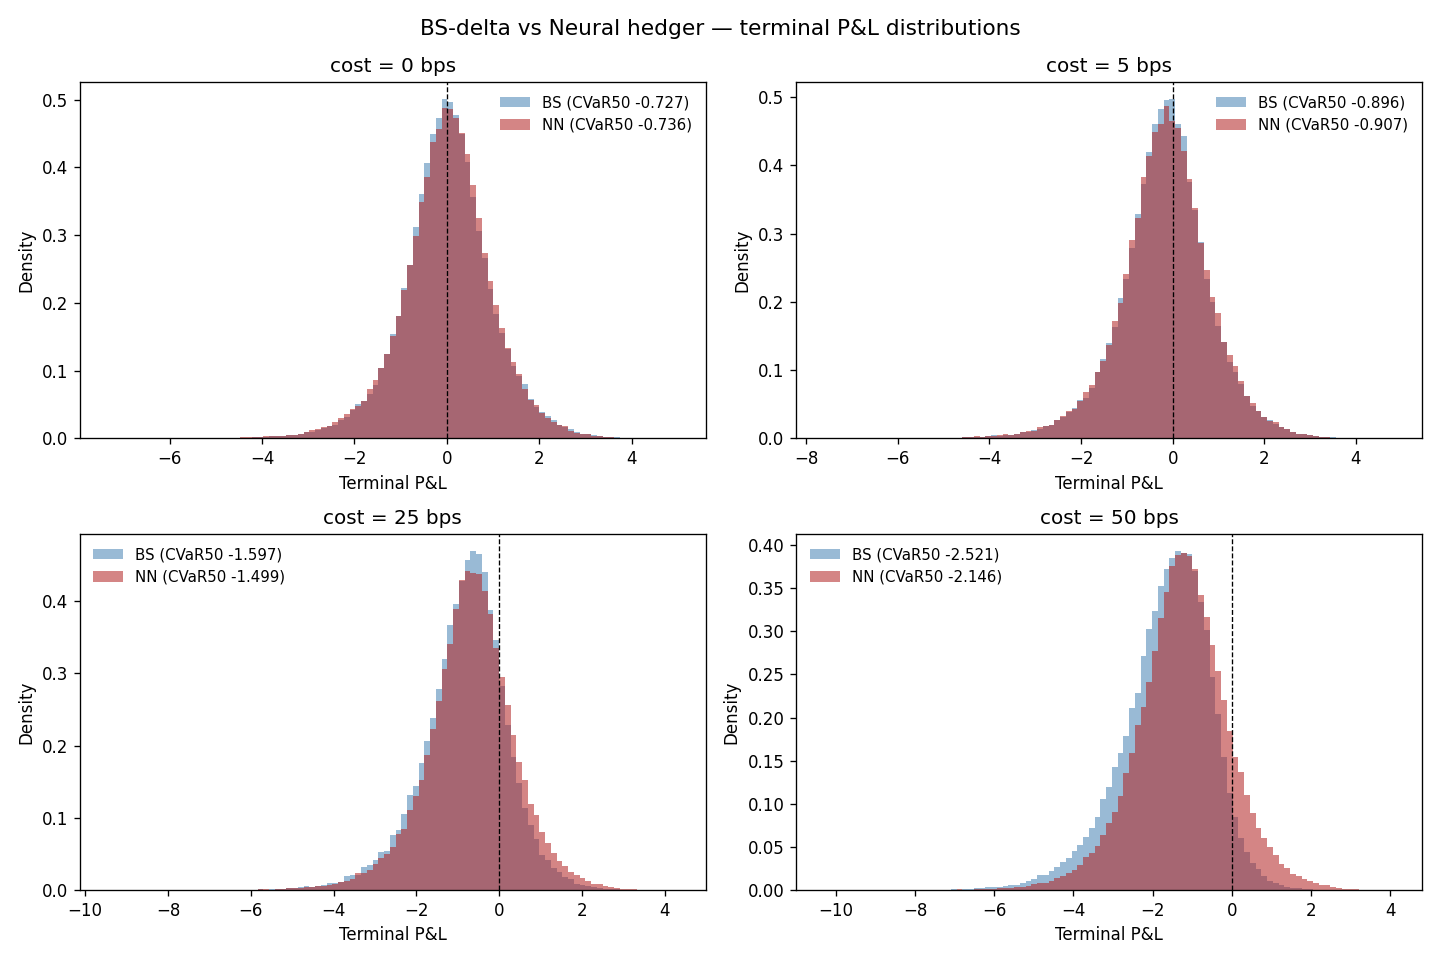

In [6]:
Image(filename=str(RESULTS / '02_pnl_comparison.png'))

The 2x2 P&L histograms make the qualitative trade-off legible: at high cost, the NN distribution is *wider* than BS but *less left-skewed*. CVaR-50% rewards exactly that trade-off — the policy gives up some centrality for materially better tails.

## 6. Interpreting the learned policy

Binning every `(S_n, h_NN - h_BS)` pair from the held-out set by spot, and plotting the conditional mean position difference per cost level.

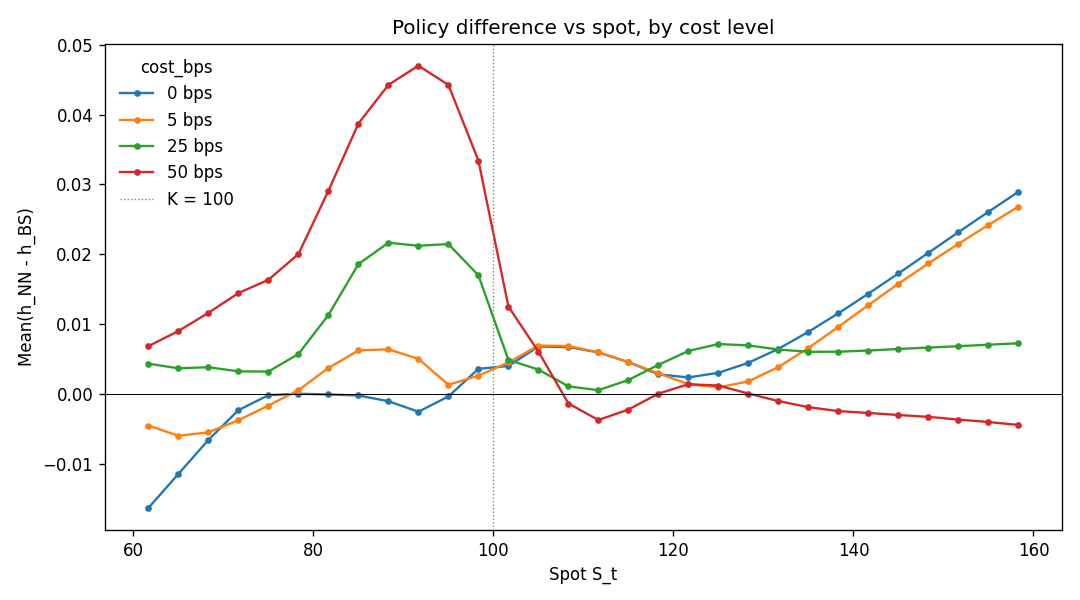

In [7]:
Image(filename=str(RESULTS / '02_policy_difference.png'))

The 0- and 5-bps lines hover around zero. The 25- and 50-bps lines have clear S-shape: the NN holds *more* than BS in the slightly-OTM region (S in [85, 100], peak roughly +0.047 shares above BS at 50 bps), and *less* than BS in the deep-ITM tail.

The economic reading: gamma is largest around the strike, so under proportional costs that is exactly where rebalancing turnover is most expensive. The NN learns to *pre-position* — to hold a bit more delta when spot is in the slightly-OTM region from which a path is most likely to sweep through the strike, and to *not chase* every late in-the-money move that BS would. "Trade ahead, save on later rebalancing." The structure is not designed in; the network's only economic prior is the BS-delta input feature.

A single sample path makes the same point concretely:

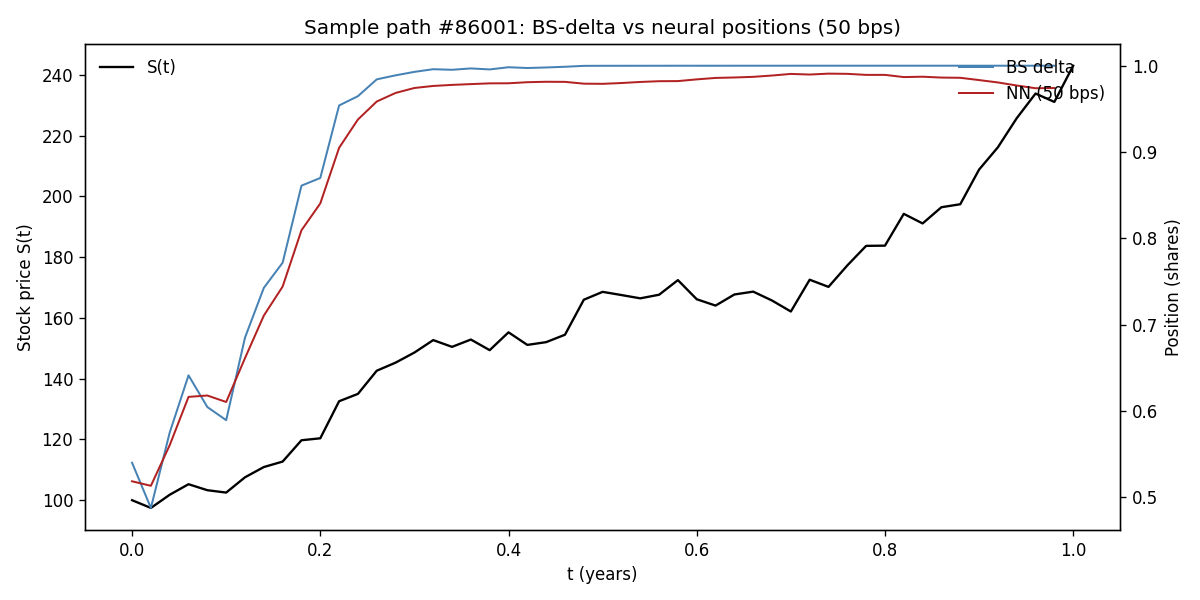

In [8]:
Image(filename=str(RESULTS / '02_position_paths.png'))

## 7. Anti-look-ahead, limitations, what's next

**Anti-look-ahead.** Three checks: (1) feature causality by inspection — every input feature at step *n* is a function of `S_0..S_n` only, including the previous-position feature, which is the network's own prior output; (2) a mechanical unit test in `tests/test_policies.py` that perturbs future path columns and asserts earlier position decisions are byte-identical; (3) evaluation-seed separation between training and held-out runs. The zero-cost gate of Section 5 is the fourth line of defence. All four passed.

**Limitations.** Simulated GBM paths only — no historical data. Constant volatility — real markets have stochastic vol (Heston, rough volatility). Linear-bps cost model is a toy. The 32x32x32 MLP is small and at 50 bps is architecture-limited (going from 200 to 500 epochs gained only +0.040 in CVaR-50%, with the convergence diagnostic below threshold). Single asset, single option.

**What's next.** Heston paths and re-training; richer features (e.g. log-moneyness x time-to-maturity interactions, second-order Greeks) and a wider network; alternative risk measures (entropic risk, quadratic, spectral). Beyond those, exotic payoffs and multi-asset hedging are the obvious larger steps. See `docs/writeup.md` for the long form.